# 0.&nbsp; User manual

- This Google Colab file implements a deep learning pipeline for an image dataset (Crop Pest and Disease Detection).

- To run this notebook, you just need to click the Colab `Run all` button (library installation and dataset loading are automated).

# 1.&nbsp; Prepare the necessary data and libraries

## 1.1.&nbsp; Verify and install necessary libraries

In [1]:
!pip install -q split-folders

In [2]:
import os
import time
import copy
import random
import splitfolders
import kagglehub
import wandb
import shutil
import hashlib
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import PIL.ImageFile
from PIL import Image
import timm

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True # Faster
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

In [3]:
from google.colab import userdata
os.environ["WANDB_API_KEY"] = userdata.get('WANDB_API_KEY')

## 1.2.&nbsp; Download and clean the dataset

In [4]:
data_path = kagglehub.dataset_download("nirmalsankalana/crop-pest-and-disease-detection")
print("Path to dataset files:", data_path)

Using Colab cache for faster access to the 'crop-pest-and-disease-detection' dataset.
Path to dataset files: /kaggle/input/crop-pest-and-disease-detection


In [5]:
def check_image_defect(path):
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            arr = np.asarray(img)
            if arr.std() < 5:
                return path
    except Exception:
        return path
    return None

def find_defects(root):
    all_paths = []
    for cls in os.listdir(root):
        cls_path = os.path.join(root, cls)
        if os.path.isdir(cls_path):
            for fname in os.listdir(cls_path):
                all_paths.append(os.path.join(cls_path, fname))
    defected_paths = []
    with ThreadPoolExecutor(max_workers=8) as executor:
        results = executor.map(check_image_defect, all_paths)
    for res in results:
        if res is not None:
            defected_paths.append(res)
    return defected_paths

defected_paths = find_defects(data_path)
print(f"Found {len(defected_paths)} defected images.")

Found 95 defected images.


In [6]:
def get_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hash_dict = {}   # hash -> original path
duplicates = []
for cls in os.listdir(data_path):
    cls_path = os.path.join(data_path, cls)
    for fname in os.listdir(cls_path):
        path = os.path.join(cls_path, fname)
        try:
            h = get_hash(path)
            if h in hash_dict:
                duplicates.append(path)
            else:
                hash_dict[h] = path
        except:
            continue
print("Total duplicates:", len(duplicates))

Total duplicates: 831


In [7]:
# Add all paths
all_paths_to_exclude = set(defected_paths).union(set(duplicates))
print(f"Total images to exclude: {len(all_paths_to_exclude)}")

Total images to exclude: 926


## 1.3.&nbsp; Split Dataset

In [8]:
CLEANED_SOURCE_DIR = "/content/cleaned_source_dataset"
OUTPUT_SPLIT_DIR = "/content/dataset"

os.makedirs(CLEANED_SOURCE_DIR, exist_ok=True)

def copy_non_excluded_images(source_root, dest_root, exclude_set):
    copied_count = 0
    for cls_name in tqdm(os.listdir(source_root), desc="Copying cleaned images"):
        source_cls_path = os.path.join(source_root, cls_name)
        dest_cls_path = os.path.join(dest_root, cls_name)
        os.makedirs(dest_cls_path, exist_ok=True)
        if os.path.isdir(source_cls_path):
            for fname in os.listdir(source_cls_path):
                source_file_path = os.path.join(source_cls_path, fname)
                if source_file_path not in exclude_set:
                    shutil.copy(source_file_path, dest_cls_path)
                    copied_count += 1
    return copied_count

print("Copying valid images to a new writable directory...")
copied_images_count = copy_non_excluded_images(data_path, CLEANED_SOURCE_DIR, all_paths_to_exclude)
print(f"Successfully copied {copied_images_count} valid images to {CLEANED_SOURCE_DIR}")

# Now split the cleaned dataset
DATA_ROOT = OUTPUT_SPLIT_DIR
splitfolders.ratio(CLEANED_SOURCE_DIR, output=DATA_ROOT, seed=seed, ratio=(0.8, 0.1, 0.1))
print(f"\nSuccessfully split cleaned data into {DATA_ROOT}")

Copying valid images to a new writable directory...


Copying cleaned images:   0%|          | 0/22 [00:00<?, ?it/s]

Successfully copied 24294 valid images to /content/cleaned_source_dataset


Copying files: 24294 files [00:05, 4634.64 files/s]


Successfully split cleaned data into /content/dataset


## 1.4.&nbsp; Custom Image Dataset

In [9]:
class ImageFolderCustom(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        self.class_to_idx = {}
        self.transform = transform
        classes = sorted(os.listdir(root))
        for i, cls in enumerate(classes):
            self.class_to_idx[cls] = i
            cls_path = os.path.join(root, cls)
            for fname in os.listdir(cls_path):
                path = os.path.join(cls_path, fname)
                self.samples.append((path, i))
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# 2.&nbsp; Exploratory Data Analysis (EDA)

Tổng số lớp: 22
Lớp nhiều ảnh nhất: Cassava bacterial blight (2073 ảnh)
Lớp ít ảnh nhất: Maize healthy (162 ảnh)


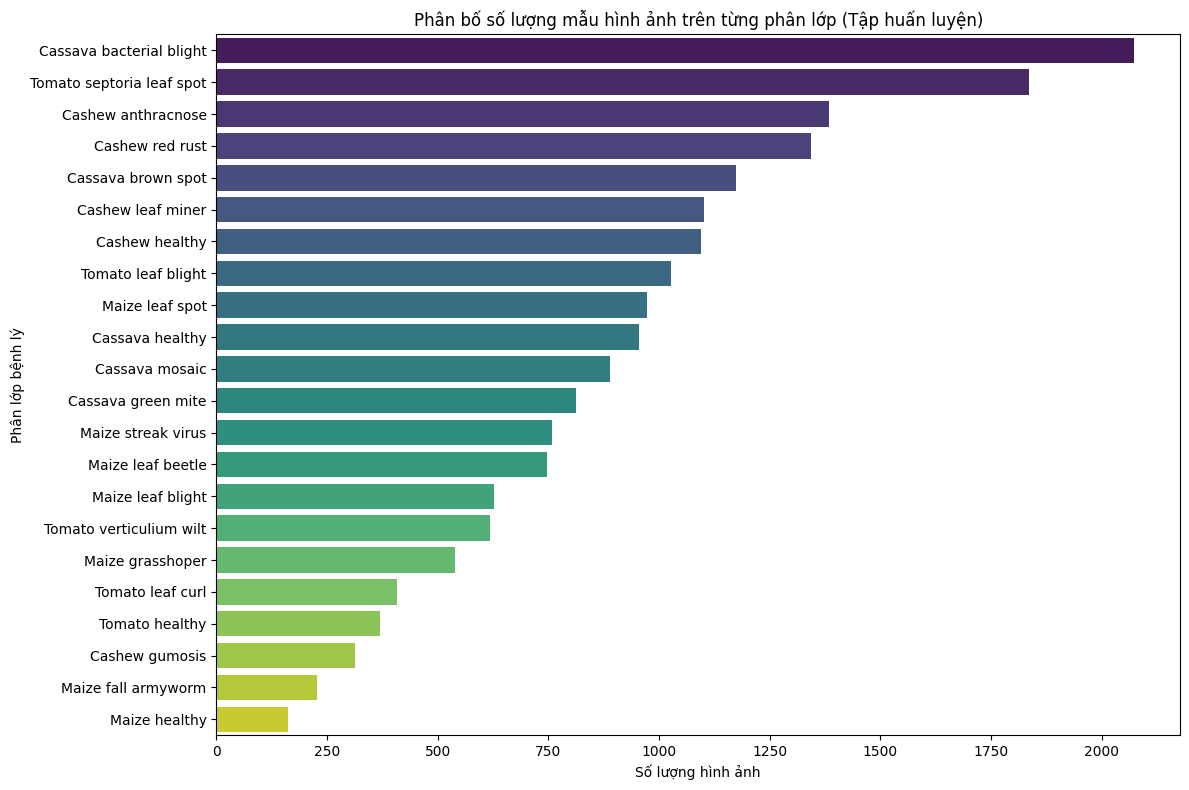

In [10]:
train_dir = '/content/dataset/train'

# Đếm số lượng ảnh trong mỗi lớp
class_counts = {}
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

# Chuyển thành DataFrame để dễ vẽ biểu đồ
df_counts = pd.DataFrame(list(class_counts.items()), columns=['Tên lớp', 'Số lượng mẫu'])
df_counts = df_counts.sort_values(by='Số lượng mẫu', ascending=False)

# In ra màn hình các thông số cơ bản
print(f"Tổng số lớp: {len(df_counts)}")
print(f"Lớp nhiều ảnh nhất: {df_counts.iloc[0]['Tên lớp']} ({df_counts.iloc[0]['Số lượng mẫu']} ảnh)")
print(f"Lớp ít ảnh nhất: {df_counts.iloc[-1]['Tên lớp']} ({df_counts.iloc[-1]['Số lượng mẫu']} ảnh)")

# Vẽ biểu đồ cột
plt.figure(figsize=(12, 8))
sns.barplot(x='Số lượng mẫu', y='Tên lớp', hue='Tên lớp', data=df_counts, palette='viridis')
plt.title('Phân bố số lượng mẫu hình ảnh trên từng phân lớp (Tập huấn luyện)')
plt.xlabel('Số lượng hình ảnh')
plt.ylabel('Phân lớp bệnh lý')
plt.tight_layout()
plt.show()

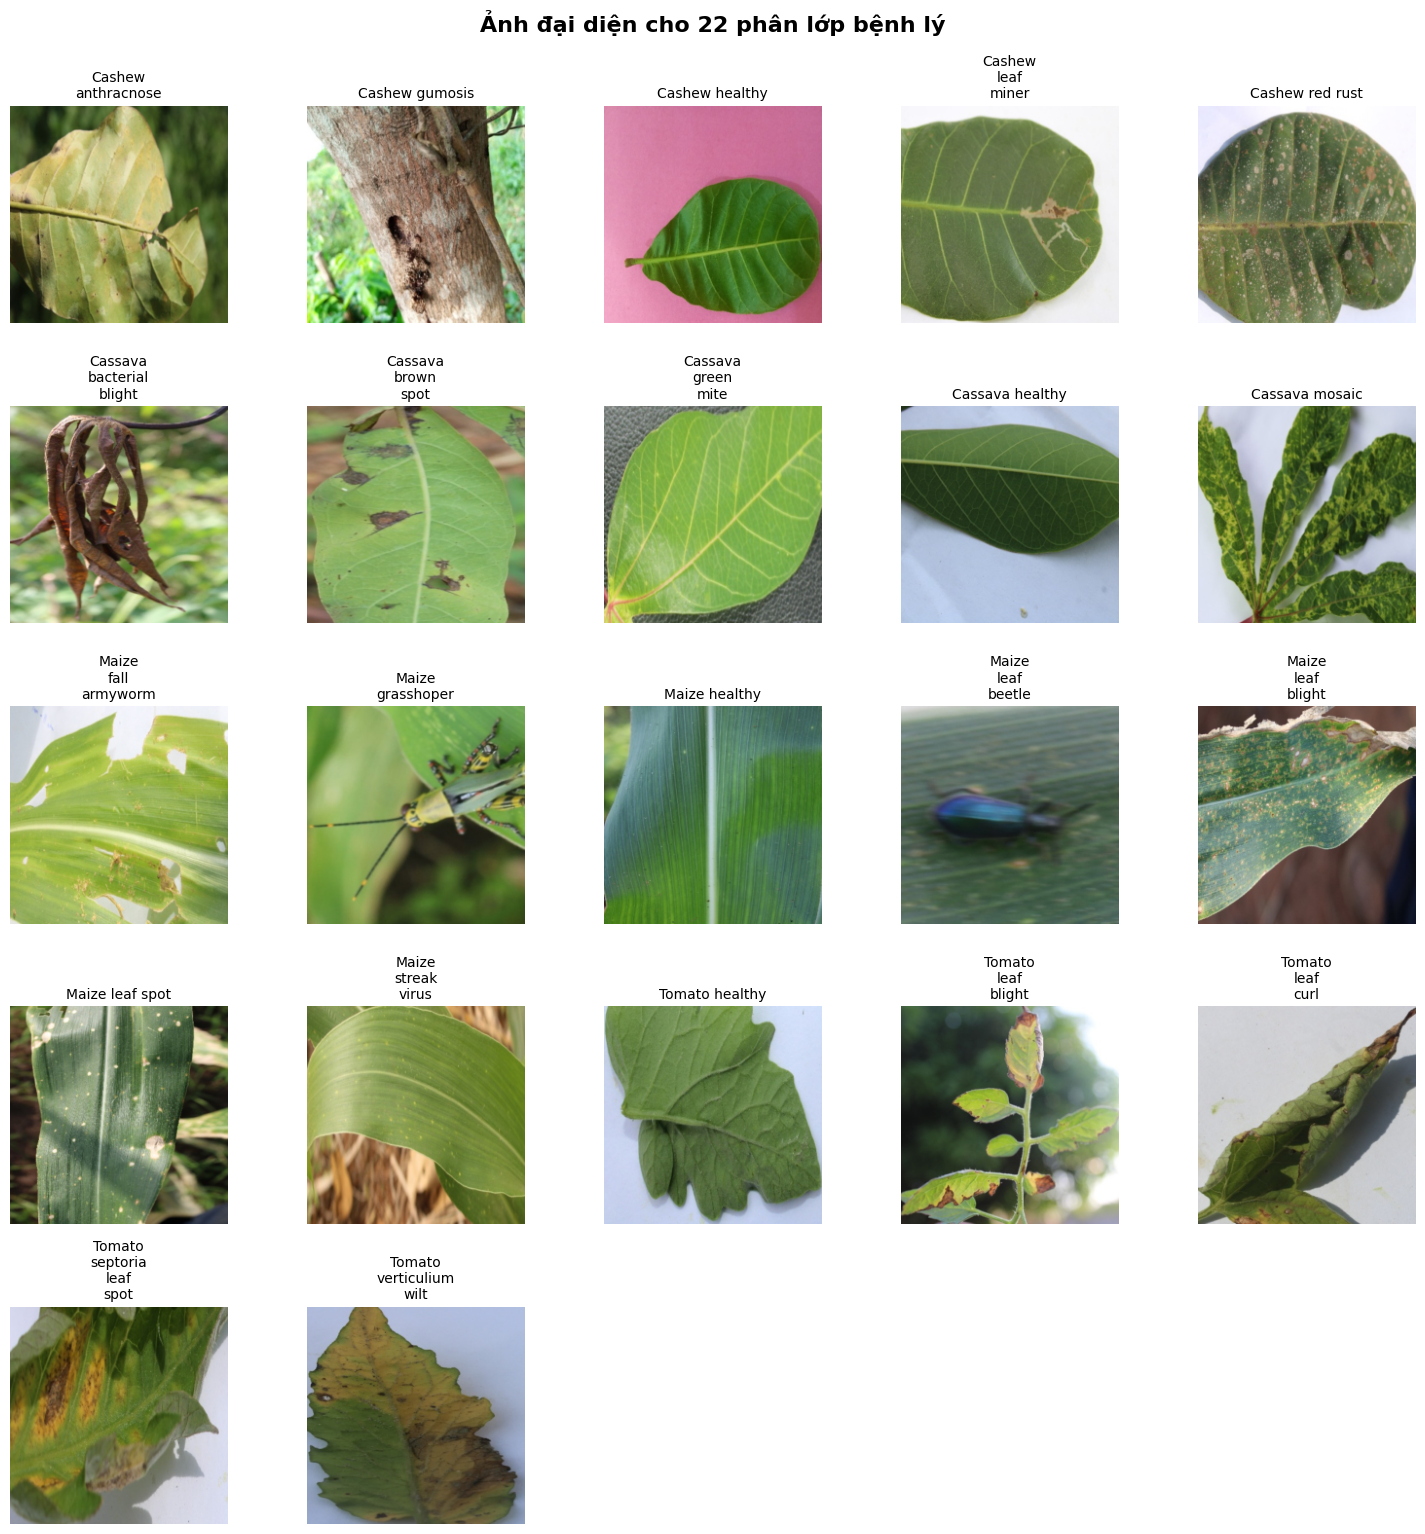

In [11]:
def display_random_images(image_custom_dataset):
    class_names_list = [image_custom_dataset.idx_to_class[i] for i in sorted(image_custom_dataset.idx_to_class.keys())]
    num_classes = len(class_names_list)
    cols = 5
    rows = (num_classes + cols - 1) // cols
    fig = plt.figure(figsize=(15, rows * 3))

    for i, class_label in image_custom_dataset.idx_to_class.items():
        class_indices = [idx for idx, (_, label) in enumerate(image_custom_dataset.samples) if label == i]
        if not class_indices:
            continue
        # Lấy ngẫu nhiên 1 ảnh đại diện cho lớp này
        sample_idx = random.choice(class_indices)
        img_tensor, _ = image_custom_dataset[sample_idx]
        img = transforms.ToPILImage()(img_tensor)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)

        # Ngắt dòng nếu tên lớp quá dài để tránh chữ đè lên nhau
        short_title = class_label.replace(' ', '\n') if len(class_label) > 15 else class_label
        plt.title(short_title, fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.suptitle("Ảnh đại diện cho 22 phân lớp bệnh lý", y=1.02, fontsize=16, fontweight='bold')
    plt.show()

simple_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
])

dataset = ImageFolderCustom(os.path.join(DATA_ROOT, 'train'), simple_transform)
display_random_images(dataset)

In [12]:
CLASS_NAMES = [dataset.idx_to_class[i] for i in sorted(dataset.idx_to_class.keys())]
print(f"Detected {len(CLASS_NAMES)} classes: {CLASS_NAMES}")

Detected 22 classes: ['Cashew anthracnose', 'Cashew gumosis', 'Cashew healthy', 'Cashew leaf miner', 'Cashew red rust', 'Cassava bacterial blight', 'Cassava brown spot', 'Cassava green mite', 'Cassava healthy', 'Cassava mosaic', 'Maize fall armyworm', 'Maize grasshoper', 'Maize healthy', 'Maize leaf beetle', 'Maize leaf blight', 'Maize leaf spot', 'Maize streak virus', 'Tomato healthy', 'Tomato leaf blight', 'Tomato leaf curl', 'Tomato septoria leaf spot', 'Tomato verticulium wilt']


# 3.&nbsp; Data Preprocessing

In [13]:
def preprocessing(CONFIG):
    transform_train = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    transform_val_test = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Apply transformations
    train_set_transformed = ImageFolderCustom(os.path.join(DATA_ROOT, 'train'), transform=transform_train)
    val_set_transformed = ImageFolderCustom(os.path.join(DATA_ROOT, 'val'), transform=transform_val_test)
    test_set_transformed = ImageFolderCustom(os.path.join(DATA_ROOT, 'test'), transform=transform_val_test)

    num_workers = CONFIG['num_workers']
    train_loader = DataLoader(
        dataset=train_set_transformed,
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        num_workers=num_workers, pin_memory=True, persistent_workers=True,
        prefetch_factor=2
    )
    val_loader = DataLoader(
        dataset=val_set_transformed,
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=num_workers, pin_memory=True, persistent_workers=True,
        prefetch_factor=2
    )
    test_loader = DataLoader(
        dataset=test_set_transformed,
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=num_workers, pin_memory=True, persistent_workers=True,
        prefetch_factor=2
    )

    return train_loader, val_loader, test_loader

# 4.&nbsp; Helper for Backbone Freezing

In [14]:
def get_model_params_groups(model):
    head_names = ['head', 'fc', 'classifier']
    found_head = None

    # 1. Detect the head attribute name
    for name in head_names:
        if hasattr(model, name):
            found_head = name
            break
    if not found_head:
        raise ValueError(f"Could not find classifier head. Model has keys: {list(model.state_dict().keys())[:5]}")

    # 2. Separate Parameters
    head_params = []
    backbone_params = []
    for name, param in model.named_parameters():
        if name.startswith(found_head):
            head_params.append(param)
        else:
            backbone_params.append(param)
    return head_params, backbone_params, found_head

# 5.&nbsp; Train and Eval per epoch

In [24]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = 0
    correct = 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        with autocast(DEVICE.type):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()

    return running_loss / len(loader.dataset), correct / len(loader.dataset)


@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    all_labels = []
    all_preds = []

    for images, labels in tqdm(loader, desc="Val/Test", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with autocast(DEVICE.type):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())

    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return running_loss / len(loader.dataset), correct / len(loader.dataset), f1_macro


# 6.&nbsp; Early Stopping

In [16]:
class EarlyStopping:
    def __init__(self, path, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.min_delta:
            # No significant improvement
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            # Improvement found
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

WandB or TensorBoard (tensorflow)

# 7.&nbsp; Core Training and Testing Function

In [21]:
def train_and_test(CONFIG, save_file, comparison=False):
    wandb.init(
        project="co3133-btl1-image",
        name=f"run_{CONFIG['model_name']}",
        config=CONFIG
    )

    freeze_epochs, finetune_epochs, warmup_epochs = CONFIG['freeze_epochs'], CONFIG['finetune_epochs'], CONFIG['warmup_epochs']
    patience, min_delta = CONFIG['patience'], CONFIG['min_delta']

    train_loader, val_loader, test_loader = preprocessing(CONFIG)
    model = timm.create_model(CONFIG['model_name'], pretrained=True, num_classes=len(CLASS_NAMES))
    model = model.to(DEVICE)

    # Calculate class weights for CrossEntropy
    class_to_idx = dataset.class_to_idx
    num_classes = len(class_to_idx)
    ordered_counts = [0] * num_classes
    for class_name, count in class_counts.items():
        idx = class_to_idx[class_name]
        ordered_counts[idx] = count

    ordered_counts = np.array(ordered_counts)
    weights = 1.0 / ordered_counts
    weights = weights / np.sum(weights) * num_classes
    class_weights_tensor = torch.FloatTensor(weights).to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
    scaler = GradScaler(DEVICE.type)

    # ------------------ FREEZE PHASE ------------------
    start_time_train = time.time()
    print("Stage 1: Frozen backbone training")
    head_params, backbone_params, head_name = get_model_params_groups(model)
    for param in backbone_params:
        param.requires_grad = False
    for param in head_params:
        param.requires_grad = True

    optimizer_s1 = optim.AdamW(head_params, lr=CONFIG['freeze_lr'])
    for epoch in range(freeze_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_s1, scaler)
        val_loss, val_acc, val_f1_macro = eval_one_epoch(model, val_loader, criterion)

        wandb.log({
            "stage": 1,
            "epoch": epoch + 1,
            "train_loss": tr_loss,
            "train_acc": tr_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1_macro": val_f1_macro,
            "learning_rate": optimizer_s1.param_groups[0]['lr']
        })

        print(f"[Epoch {epoch+1}/{freeze_epochs}] Train Loss: {tr_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1-Macro: {val_f1_macro:.4f}")

    # ------------------ FINETUNE PHASE ------------------
    print("Stage 2: Full fine-tuning")
    for param in model.parameters():
        param.requires_grad = True

    head_params, backbone_params, _ = get_model_params_groups(model)
    # EfficientNet specific optimizer: RMSprop
    if CONFIG['model_name'] == 'efficientnet_b0':
        optimizer_s2 = optim.RMSprop(
            [
                {'params': backbone_params, 'lr': CONFIG['backbone_lr']},
                {'params': head_params, 'lr': CONFIG['head_lr']}
            ],
            alpha=0.9,
            eps=1e-3,
            weight_decay=1e-5,
            momentum=0.9
        )
    else: # For other models, use AdamW
        optimizer_s2 = optim.AdamW([
            {'params': backbone_params, 'lr': CONFIG['backbone_lr']}, # Slow learning for backbone
            {'params': head_params,     'lr': CONFIG['head_lr']}      # Fast learning for head
        ], weight_decay=0.01)

    scheduler_warmup = LinearLR(optimizer_s2, start_factor=0.01, total_iters=warmup_epochs)
    scheduler_cosine = CosineAnnealingLR(optimizer_s2, T_max=finetune_epochs - warmup_epochs, eta_min=1e-6)
    scheduler_s2 = SequentialLR(
        optimizer_s2,
        schedulers=[scheduler_warmup, scheduler_cosine],
        milestones=[warmup_epochs]
    )
    early_stopper = EarlyStopping(save_file, patience=patience, min_delta=min_delta)

    for epoch in range(finetune_epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_s2, scaler)
        val_loss, val_acc, val_f1_macro = eval_one_epoch(model, val_loader, criterion)

        scheduler_s2.step()

        wandb.log({
            "stage": 2,
            "epoch": freeze_epochs + epoch + 1,
            "train_loss": tr_loss,
            "train_acc": tr_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1_macro": val_f1_macro,
            "lr_backbone": optimizer_s2.param_groups[0]['lr'],
            "lr_head": optimizer_s2.param_groups[1]['lr']
        })

        print(f"[Epoch {epoch+1}/{finetune_epochs}] Train Loss: {tr_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1-Macro: {val_f1_macro:.4f}")

        early_stopper(val_loss, model) # Also handle saving best model

        if early_stopper.early_stop:
            print("Early stopping triggered! Training stopped.")
            break

    end_time_train = time.time()
    training_time = end_time_train - start_time_train

    # ------------------ TEST ------------------
    print("Loading best model for testing...")
    model.load_state_dict(torch.load(save_file))
    model.eval()
    y_true_test, y_pred_test = [], []

    start_time_inference = time.time()
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = outputs.max(1)

            y_true_test.extend(labels.cpu().numpy())
            y_pred_test.extend(predicted.cpu().numpy())
    end_time_inference = time.time()
    inference_time = end_time_inference - start_time_inference

    accuracy = accuracy_score(y_true_test, y_pred_test)
    precision = precision_score(y_true_test, y_pred_test, average='macro', zero_division=0)
    recall = recall_score(y_true_test, y_pred_test, average='macro', zero_division=0)
    f1 = f1_score(y_true_test, y_pred_test, average='macro', zero_division=0)

    wandb.log({
        "test_accuracy": accuracy,
        "test_precision": precision,
        "test_recall": recall,
        "test_f1": f1,
        "training_time": training_time,
        "inference_time": inference_time
    })
    wandb.finish()

    if not comparison:
        print("=== Test Metrics ===")
        print(f"Accuracy : {accuracy*100:.2f}%")
        print(f"Precision: {precision*100:.2f}%")
        print(f"Recall   : {recall*100:.2f}%")
        print(f"F1-score : {f1*100:.2f}%")
        print(f"Training Time: {training_time:.2f} seconds")
        print(f"Inference Time: {inference_time:.2f} seconds")
        print("\nDetailed classification report:")
        print(classification_report(y_true_test, y_pred_test, digits=4))

        cm = confusion_matrix(y_true_test, y_pred_test)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues', values_format='d')
        plt.title("Confusion Matrix")
        plt.show()
        return
    else:
        # No need to print all details for comparison mode, just return the metrics
        print(f"Final Test Accuracy: {accuracy:.4f}")
        print(f"Final Test Precision: {precision:.4f}")
        print(f"Final Test Recall: {recall:.4f}")
        print(f"Final Test F1: {f1:.4f}")

        return {
            'model_name': CONFIG['model_name'],
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'training_time': training_time,
            'inference_time': inference_time
        }


bảng so sánh: metric nào càng cao càng tốt (mũi tên lên) / nhỏ càng tốt (mũi tên xuống)

dùng plotly với seaborn là đẹp nhất

# 8.&nbsp; Comparison

In [25]:
# 1. Khai báo danh sách cấu hình cho 4 mô hình
# Sử dụng một cấu hình gốc chung để đảm bảo tính công bằng khi so sánh
base_config = {
    'num_workers': 2,
    'freeze_epochs': 15,
    'finetune_epochs': 0,
    'warmup_epochs': 0,
    'patience': 4,
    'min_delta': 0.001
}

models_to_run = [
    {
        **base_config,
        'model_name': 'resnet50',
        "batch_size": 64,
        'freeze_lr': 1e-3,
        'backbone_lr': 1e-5,
        'head_lr': 5e-4
    },
    {
        **base_config,
        'model_name': 'efficientnet_b0',
        "batch_size": 64,
        # EfficientNet hội tụ tốt hơn với tốc độ học cao hơn một chút
        'freeze_lr': 2e-3,
        'backbone_lr': 2e-5,
        'head_lr': 1e-3
    },
    {
        **base_config,
        'model_name': 'vit_base_patch16_224',
        "batch_size": 16,
        # ViT rất nhạy cảm, cần tốc độ học của thân mạng nhỏ để không phá vỡ trọng số
        'freeze_lr': 1e-3,
        'backbone_lr': 5e-6,
        'head_lr': 3e-4
    },
    {
        **base_config,
        'model_name': 'swin_tiny_patch4_window7_224',
        "batch_size": 16,
        'freeze_lr': 1e-3,
        'backbone_lr': 1e-5,
        'head_lr': 5e-4
    }
]

# 2. Vòng lặp thực thi
results_list = []

for cfg in models_to_run:
    model_name = cfg['model_name']
    print(f"\n{'='*60}")
    print(f"BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH: {model_name.upper()}")
    print(f"{'='*60}")

    save_file = f"best_checkpoint_{model_name}.pth"

    # Giả định train_set, val_set, test_set đã được khởi tạo từ trước
    result = train_and_test(
        CONFIG=cfg,
        save_file=save_file,
        comparison=True
    )

    results_list.append(result)

# 3. Tổng hợp và trực quan hóa kết quả so sánh
print("\n" + "="*60)
print("HOÀN TẤT THỰC NGHIỆM - BẢNG TỔNG HỢP KẾT QUẢ")
print("="*60)

# Chuyển đổi sang DataFrame để hiển thị bảng đẹp mắt
df_results = pd.DataFrame(results_list)
# Rút gọn tên mô hình để vẽ biểu đồ không bị tràn viền
df_results['short_name'] = ['ResNet50', 'EfficientNet-B0', 'ViT-Base', 'Swin-Tiny']
df_results = df_results[['short_name', 'accuracy', 'precision', 'recall', 'f1', 'training_time', 'inference_time']]

print(df_results.to_markdown(index=False))

# Vẽ biểu đồ so sánh F1-Score (Thước đo quan trọng nhất cho dữ liệu mất cân bằng)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='short_name', y='f1', data=df_results, palette='mako')
plt.title('So sánh điểm F1-Macro giữa các kiến trúc mạng', fontsize=14, fontweight='bold')
plt.xlabel('Kiến trúc mô hình', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, 1.1)

# Thêm giá trị trực tiếp lên đầu các cột
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

# Vẽ biểu đồ so sánh Tốc độ suy luận
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='short_name', y='inference_time', data=df_results, palette='flare')
plt.title('So sánh thời gian suy luận trên tập kiểm thử', fontsize=14, fontweight='bold')
plt.xlabel('Kiến trúc mô hình', fontsize=12)
plt.ylabel('Thời gian (giây)', fontsize=12)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()


BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH: RESNET50


Stage 1: Frozen backbone training


Train:   0%|          | 0/304 [00:00<?, ?it/s]

KeyboardInterrupt: 

Final Test Accuracy: 0.8285
Final Test Precision: 0.8085
Final Test Recall: 0.8530
Final Test F1: 0.8226